In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
DATA_FILE = r"C:\Users\rouna\Documents\BITS Pilani WILP\Semester 4\Dissertation\AIMLCZG628T\datasets\Industrial_Equipment_Monitoring_Dataset\equipment_anomaly_data.csv"

--- 1. Loading and Inspecting Data ---
Successfully loaded 'C:\Users\rouna\Documents\BITS Pilani WILP\Semester 4\Dissertation\AIMLCZG628T\datasets\Industrial_Equipment_Monitoring_Dataset\equipment_anomaly_data.csv'.

[INFO] First 5 rows of the dataset:
   temperature   pressure  vibration   humidity   equipment       location  \
0    58.180180  25.029278   0.606516  45.694907     Turbine        Atlanta   
1    75.740712  22.954018   2.338095  41.867407  Compressor        Chicago   
2    71.358594  27.276830   1.389198  58.954409     Turbine  San Francisco   
3    71.616985  32.242921   1.770690  40.565138        Pump        Atlanta   
4    66.506832  45.197471   0.345398  43.253795        Pump       New York   

   faulty  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  

[INFO] Dataframe information summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       -

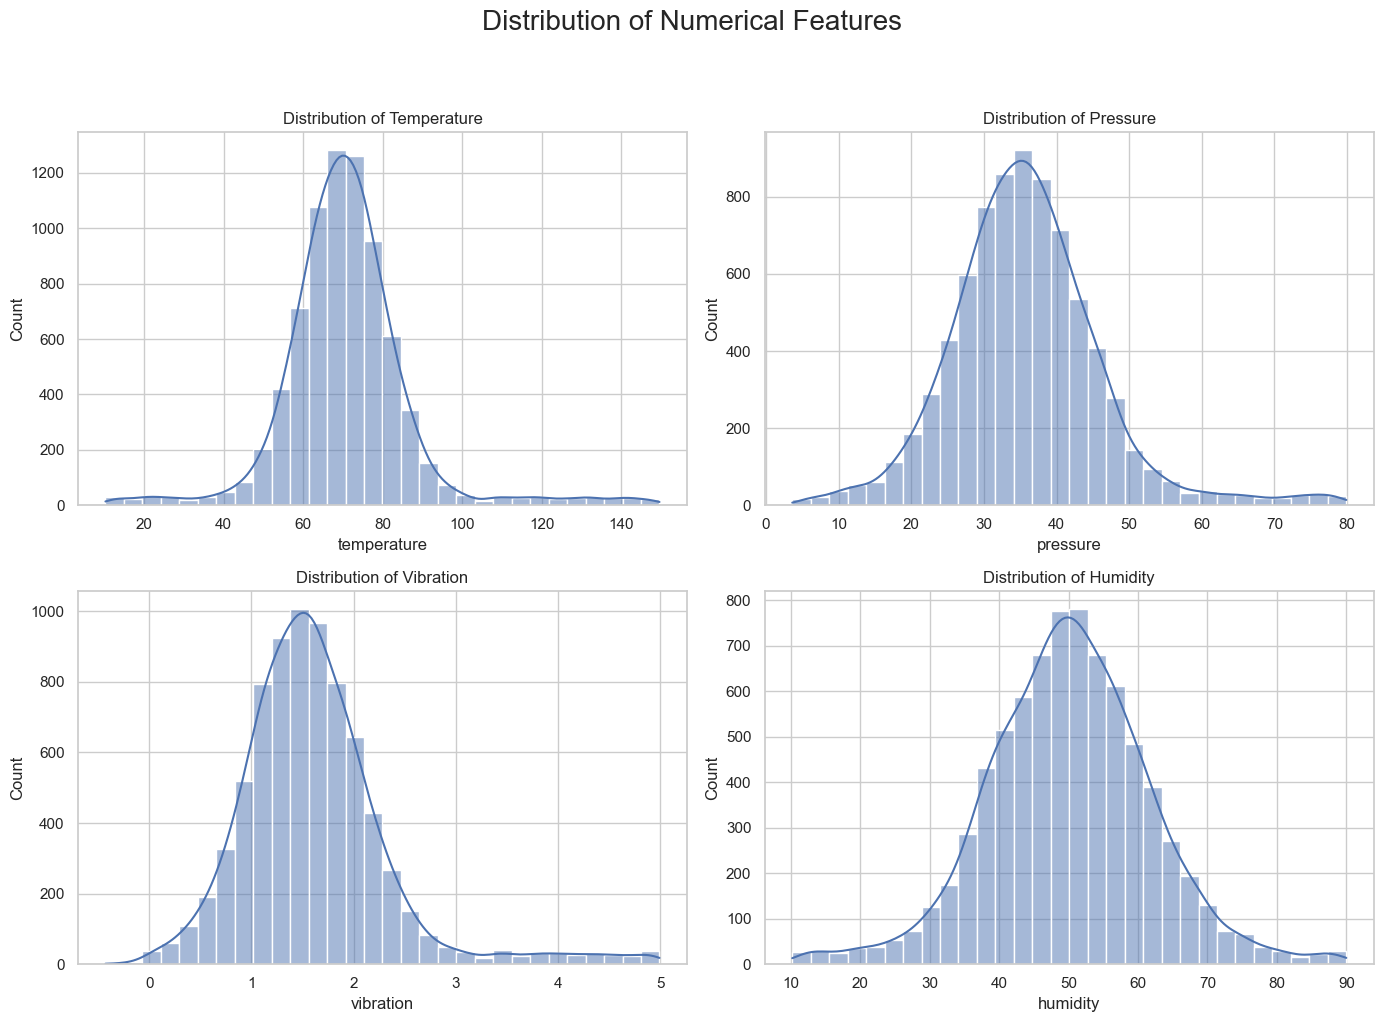


[INFO] Plotting distributions for categorical features...


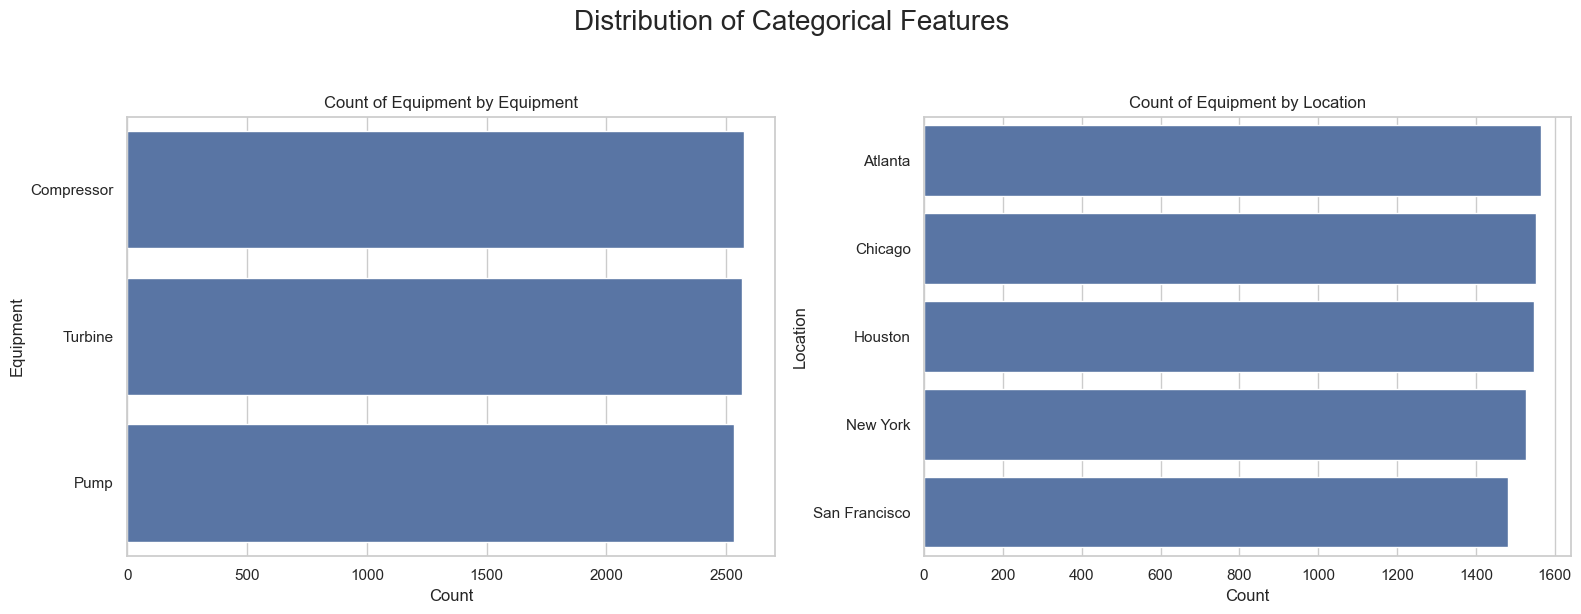


[INFO] Plotting distribution for the target variable 'faulty'...


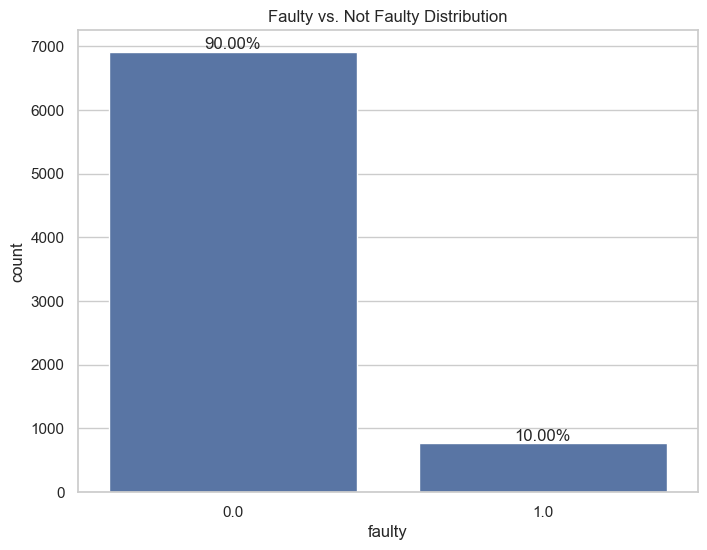


--- 4. Bivariate Analysis ---

[INFO] Analyzing numerical features against the 'faulty' status...


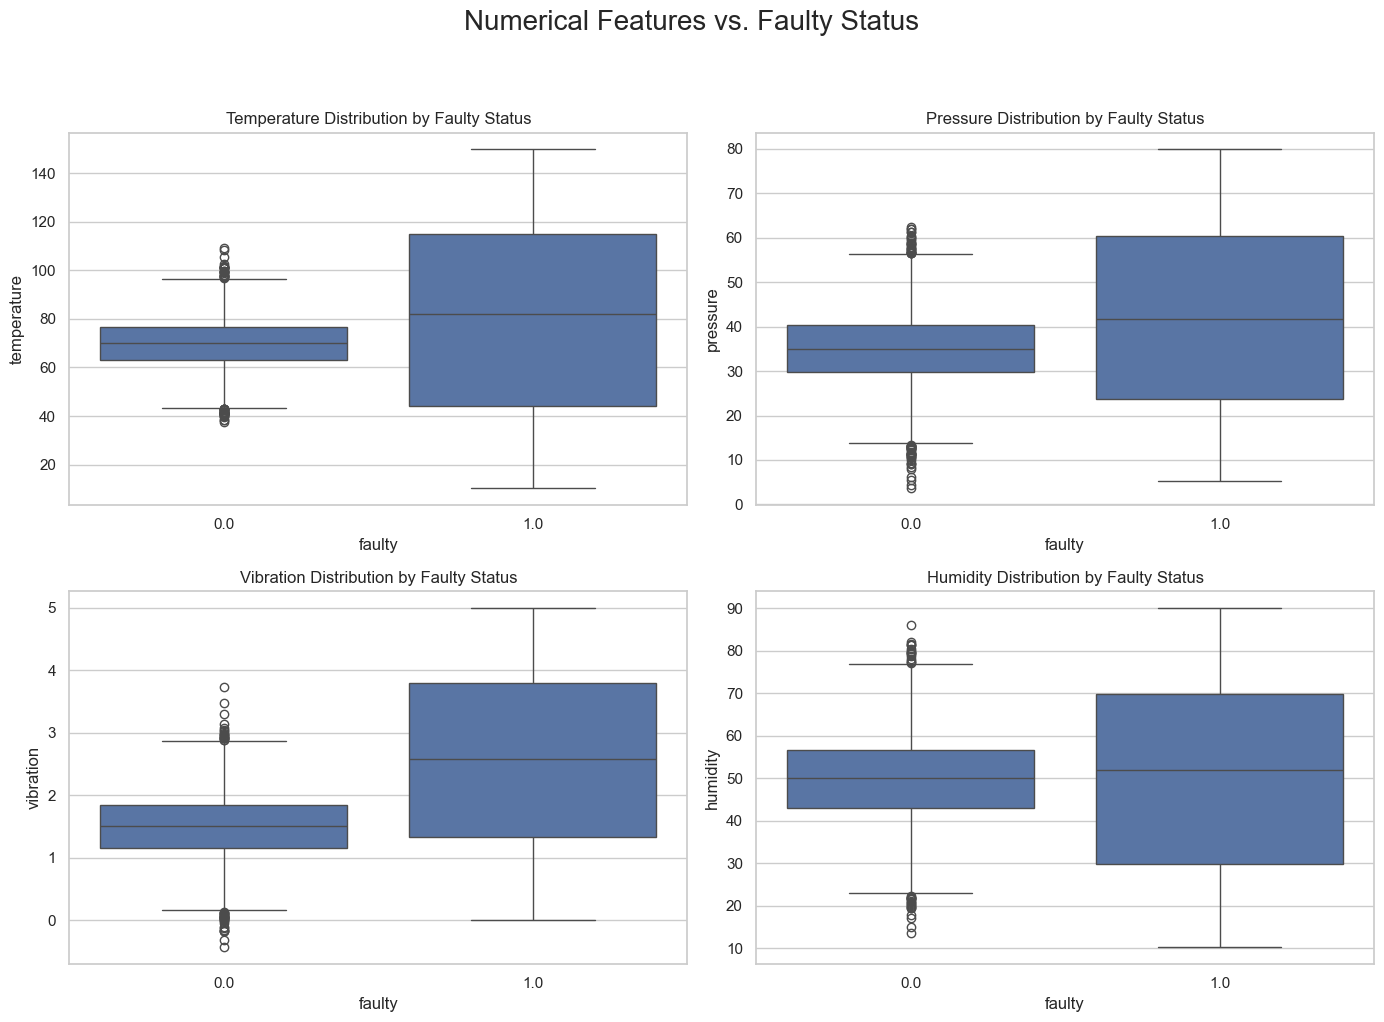


[INFO] Analyzing categorical features against the 'faulty' status...

Fault Rate by Equipment:
equipment
Turbine       0.100585
Compressor    0.099883
Pump          0.099448
Name: faulty, dtype: float64


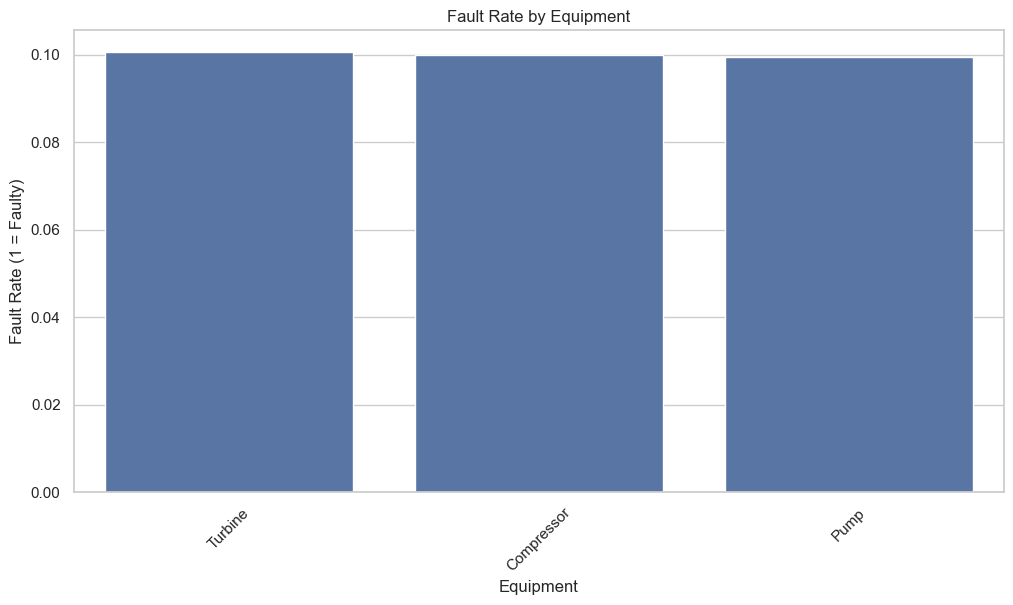


Fault Rate by Location:
location
San Francisco    0.114787
Chicago          0.103026
Houston          0.098837
New York         0.093709
Atlanta          0.090153
Name: faulty, dtype: float64


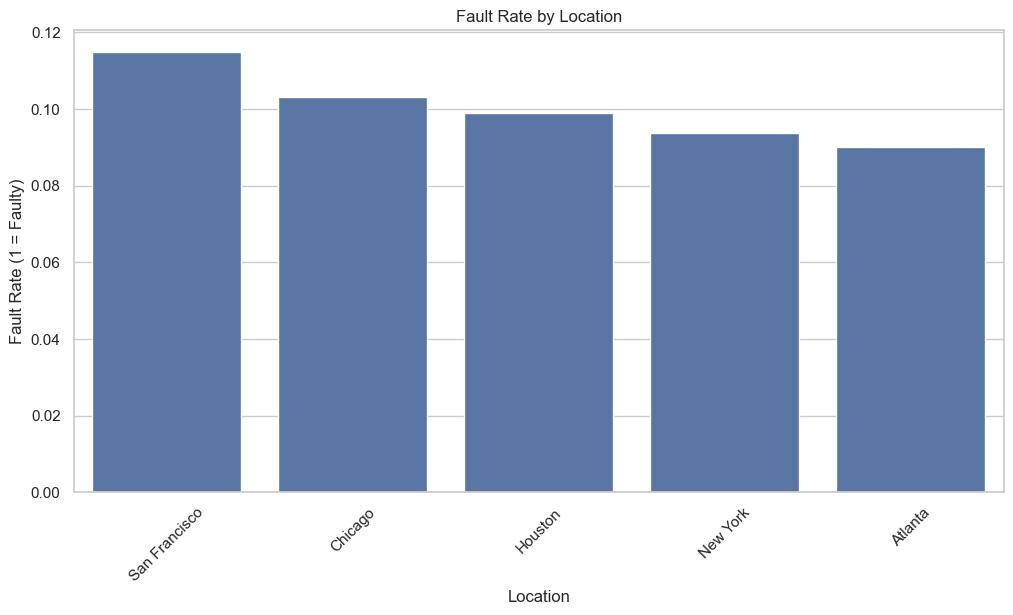


[INFO] Generating correlation matrix heatmap...


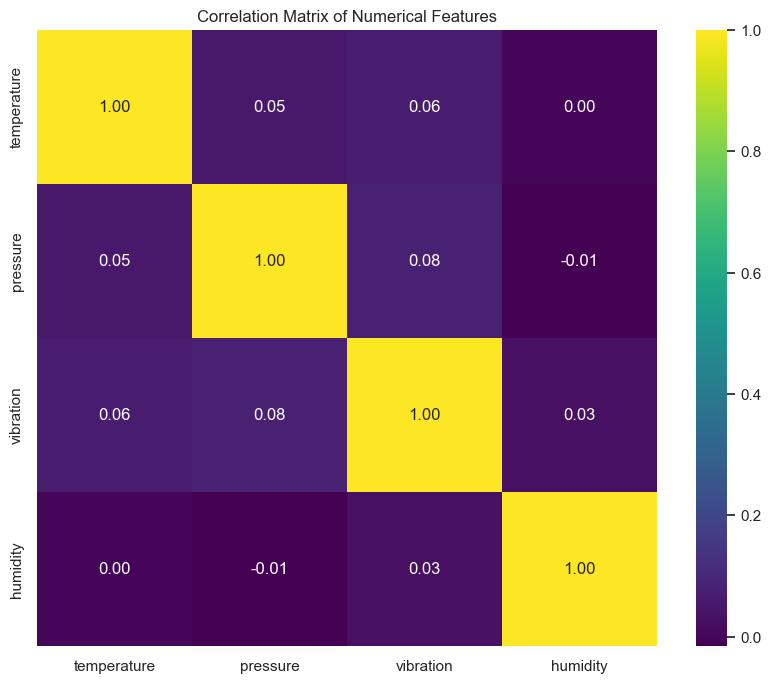


--- 5. Multivariate Analysis ---

[INFO] Generating pair plot, colored by 'faulty' status...


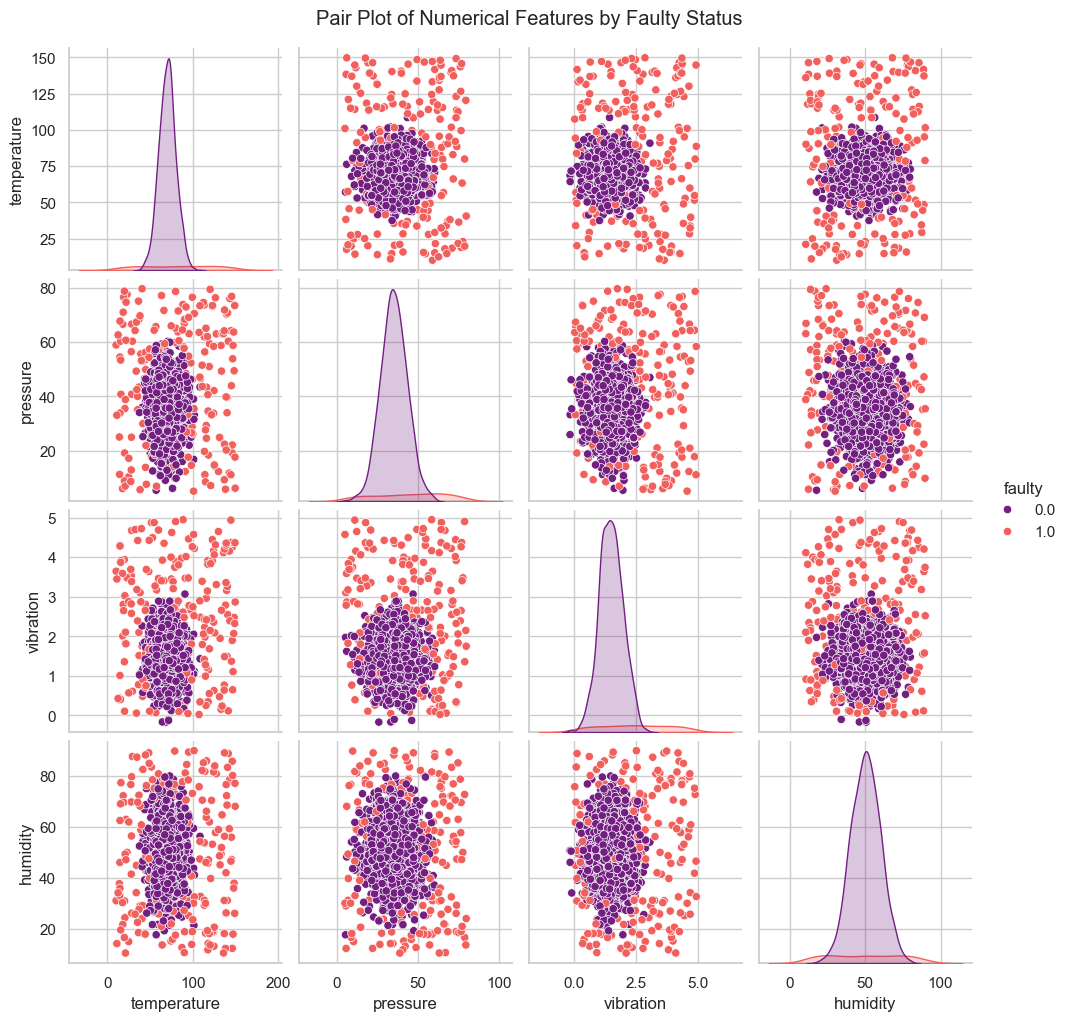


[INFO] Analyzing numerical readings across equipment types...


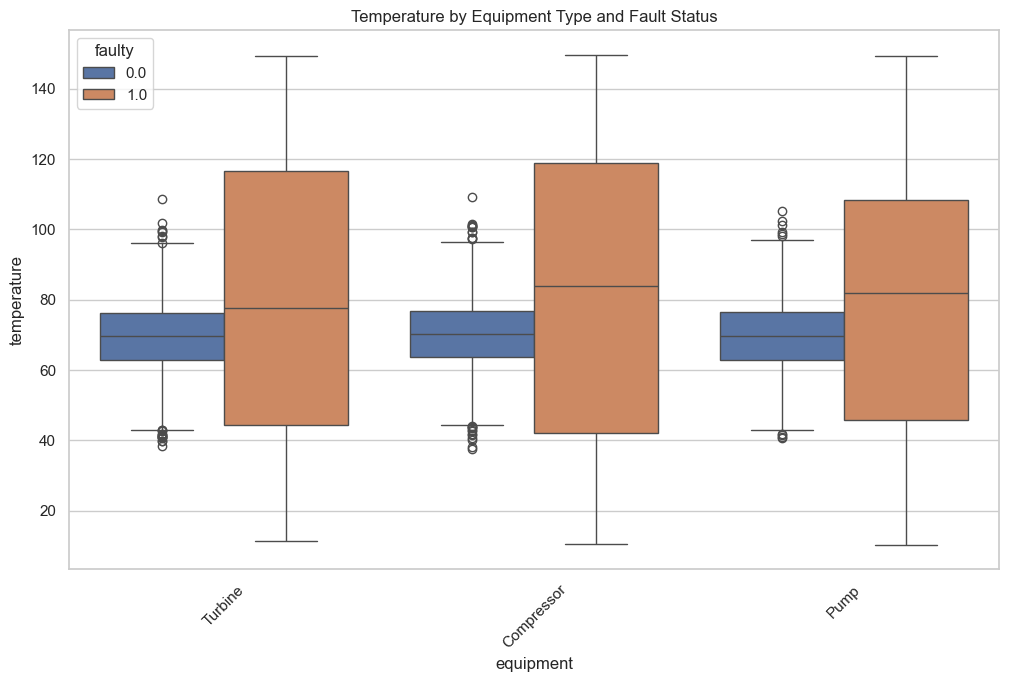

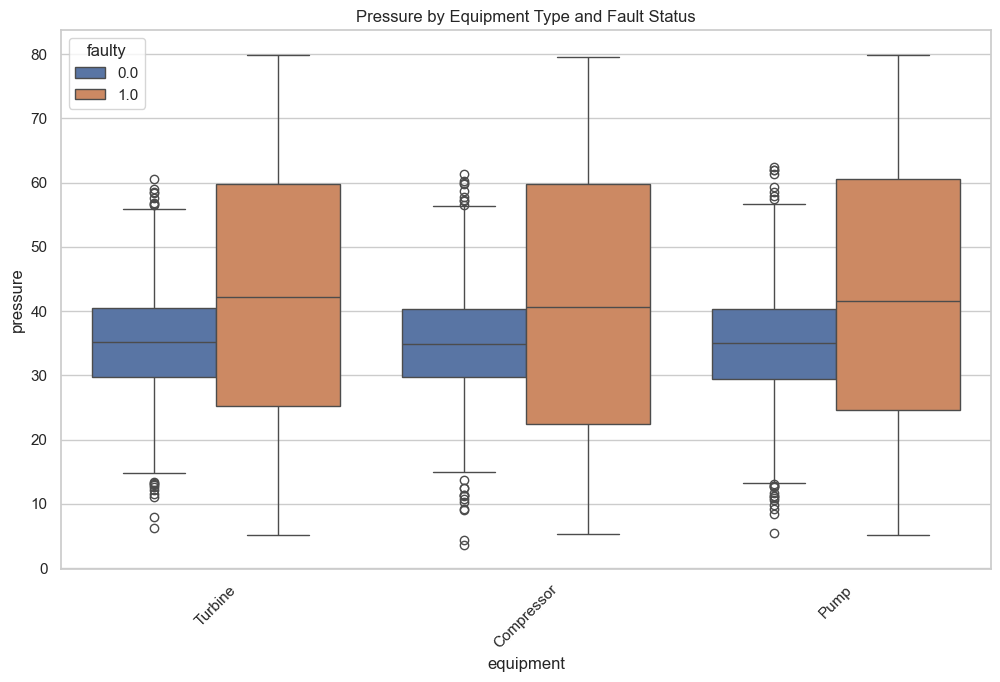

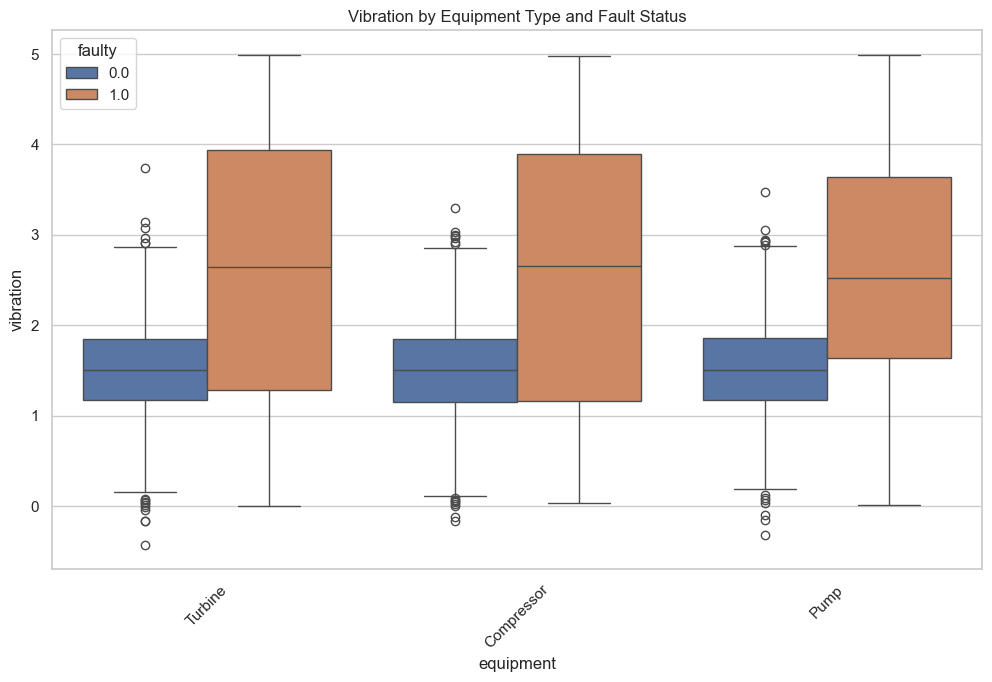

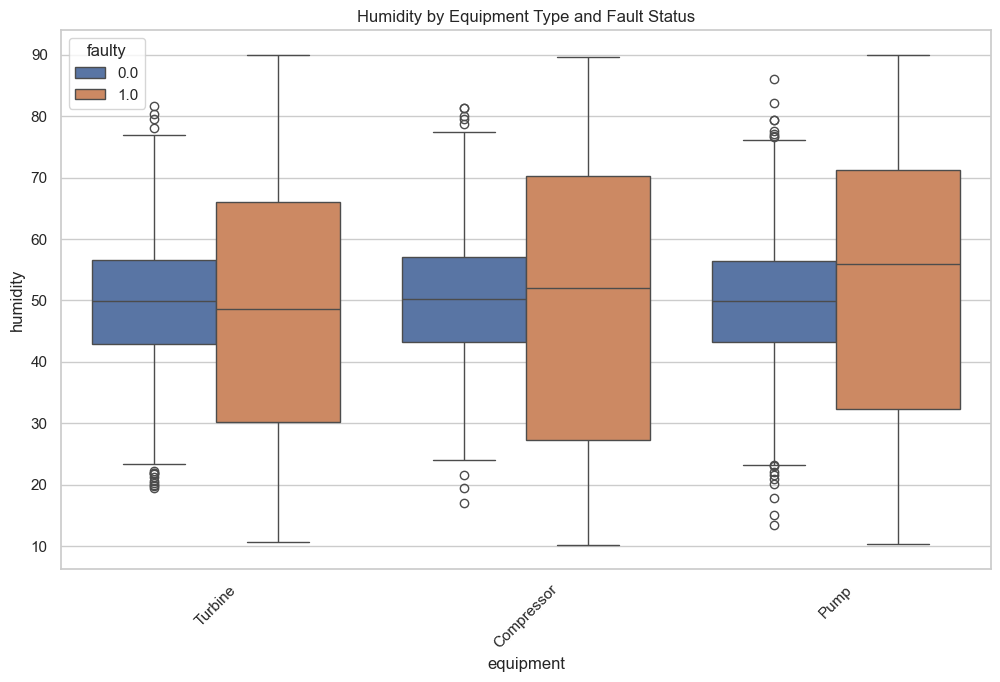


--- Comprehensive EDA Complete ---


In [6]:
# main.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def perform_comprehensive_eda(file_path):
    """
    Performs a comprehensive Exploratory Data Analysis (EDA) on the equipment fault dataset.

    This script assumes the dataset contains the following columns as per user specification:
    'temperature', 'pressure', 'vibration', 'humidity', 'equipment', 'location', 'faulty',
    and optionally 'timestamp'.

    Args:
        file_path (str): The path to the CSV data file.
    """
    # --- 1. Data Loading and Initial Inspection ---
    print("--- 1. Loading and Inspecting Data ---")
    try:
        # Load the dataset from the provided file path into a pandas DataFrame.
        df = pd.read_csv(file_path)
        print(f"Successfully loaded '{file_path}'.")
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    except Exception as e:
        print(f"An error occurred: {e}")
        print("\n[IMPORTANT] Please ensure the CSV file contains the specified columns: \n'temperature', 'pressure', 'vibration', 'humidity', 'equipment', 'location', 'faulty'")
        return

    # Display the first 5 rows to get a feel for the data.
    print("\n[INFO] First 5 rows of the dataset:")
    print(df.head())

    # Get a concise summary of the DataFrame to check for data types and null values.
    print("\n[INFO] Dataframe information summary:")
    df.info()

    # Generate descriptive statistics for both numerical and categorical columns.
    print("\n[INFO] Descriptive statistics for the dataset:")
    print(df.describe(include='all'))

    # --- 2. Data Cleaning and Preprocessing ---
    print("\n--- 2. Data Cleaning and Preprocessing ---")
    # Check for missing values.
    missing_values = df.isnull().sum()
    print("\n[INFO] Missing values per column:")
    print(missing_values)
    if missing_values.sum() == 0:
        print("-> No missing values found.")
    else:
        # In a real-world scenario, we would implement a strategy like imputation here.
        print("-> Missing values detected. Consider an imputation strategy.")

    # Data Type Conversion
    # If a 'timestamp' column exists, convert it to datetime for time series analysis.
    if 'timestamp' in df.columns:
        print("\n[INFO] Converting 'timestamp' column to datetime objects.")
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        # Check if any conversions failed
        if df['timestamp'].isnull().any():
            print("-> Warning: Some timestamp values could not be parsed and were set to NaT.")
            df.dropna(subset=['timestamp'], inplace=True) # Drop rows where conversion failed


    # --- 3. Univariate Analysis (Analyzing Individual Features) ---
    print("\n--- 3. Univariate Analysis ---")
    sns.set_theme(style="whitegrid")
    
    # Define numerical and categorical features based on the new schema
    numerical_features = ['temperature', 'pressure', 'vibration', 'humidity']
    categorical_features = ['equipment', 'location']
    target = 'faulty'

    # a) Distribution of Numerical Features
    print("\n[INFO] Plotting distributions for numerical features...")
    plt.figure(figsize=(14, 10))
    plt.suptitle("Distribution of Numerical Features", fontsize=20, y=1.02)
    for i, col in enumerate(numerical_features):
        plt.subplot(2, 2, i + 1)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col.capitalize()}')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # b) Distribution of Categorical Features
    print("\n[INFO] Plotting distributions for categorical features...")
    plt.figure(figsize=(16, 6))
    plt.suptitle("Distribution of Categorical Features", fontsize=20, y=1.02)
    for i, col in enumerate(categorical_features):
        plt.subplot(1, 2, i + 1)
        sns.countplot(y=col, data=df, order=df[col].value_counts().index)
        plt.title(f'Count of Equipment by {col.capitalize()}')
        plt.xlabel('Count')
        plt.ylabel(col.capitalize())
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # c) Target Variable Distribution (Faulty vs. Not Faulty)
    print("\n[INFO] Plotting distribution for the target variable 'faulty'...")
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=target, data=df)
    plt.title('Faulty vs. Not Faulty Distribution')
    # Annotate with percentages
    total = len(df[target])
    for p in ax.patches:
        percentage = f'{(p.get_height()/total)*100:.2f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')
    plt.show()


    # --- 4. Bivariate Analysis (Analyzing Feature Relationships) ---
    print("\n--- 4. Bivariate Analysis ---")

    # a) Numerical Features vs. Target (Faulty)
    print("\n[INFO] Analyzing numerical features against the 'faulty' status...")
    plt.figure(figsize=(14, 10))
    plt.suptitle("Numerical Features vs. Faulty Status", fontsize=20, y=1.02)
    for i, col in enumerate(numerical_features):
        plt.subplot(2, 2, i + 1)
        sns.boxplot(x=target, y=col, data=df)
        plt.title(f'{col.capitalize()} Distribution by Faulty Status')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # b) Categorical Features vs. Target (Faulty)
    print("\n[INFO] Analyzing categorical features against the 'faulty' status...")
    for col in categorical_features:
        # Calculate fault rate
        fault_rate = df.groupby(col)[target].mean().sort_values(ascending=False)
        print(f"\nFault Rate by {col.capitalize()}:\n{fault_rate}")
        plt.figure(figsize=(12, 6))
        sns.barplot(x=fault_rate.index, y=fault_rate.values)
        plt.title(f'Fault Rate by {col.capitalize()}')
        plt.ylabel('Fault Rate (1 = Faulty)')
        plt.xlabel(col.capitalize())
        plt.xticks(rotation=45)
        plt.show()
    
    # c) Numerical vs. Numerical (Correlation)
    print("\n[INFO] Generating correlation matrix heatmap...")
    plt.figure(figsize=(10, 8))
    # We only correlate numerical features
    correlation_matrix = df[numerical_features].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

    # --- 5. Multivariate Analysis ---
    print("\n--- 5. Multivariate Analysis ---")

    # a) Pair Plot to see interactions, colored by the target variable
    print("\n[INFO] Generating pair plot, colored by 'faulty' status...")
    # Using a sample to keep it fast, otherwise can be slow on large datasets
    df_sample = df.sample(n=min(2000, len(df)), random_state=42)
    sns.pairplot(df_sample, hue=target, vars=numerical_features, palette='magma')
    plt.suptitle("Pair Plot of Numerical Features by Faulty Status", y=1.02)
    plt.show()

    # b) Numerical vs. Categorical Analysis
    # How do numerical readings vary across different types of equipment?
    print("\n[INFO] Analyzing numerical readings across equipment types...")
    for num_col in numerical_features:
        plt.figure(figsize=(12, 7))
        sns.boxplot(x='equipment', y=num_col, data=df, hue=target, dodge=True)
        plt.title(f'{num_col.capitalize()} by Equipment Type and Fault Status')
        plt.xticks(rotation=45)
        plt.show()
    
    # --- 6. Time Series Analysis (Optional) ---
    if 'timestamp' in df.columns:
        print("\n--- 6. Time Series Analysis ---")
        df_ts = df.set_index('timestamp')
        
        print("[INFO] Plotting vibration and temperature over time...")
        fig, ax1 = plt.subplots(figsize=(18, 7))
        
        # Plot vibration on primary y-axis
        color = 'tab:blue'
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Vibration', color=color)
        ax1.plot(df_ts.index, df_ts['vibration'], color=color, alpha=0.6, label='Vibration')
        ax1.tick_params(axis='y', labelcolor=color)

        # Create a second y-axis for temperature
        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel('Temperature (°C)', color=color)
        ax2.plot(df_ts.index, df_ts['temperature'], color=color, alpha=0.6, label='Temperature')
        ax2.tick_params(axis='y', labelcolor=color)

        # Highlight faulty points
        faulty_points = df_ts[df_ts[target] == 1]
        ax1.scatter(faulty_points.index, faulty_points['vibration'], color='black', s=50, zorder=5, label='Fault')

        fig.tight_layout()
        plt.title('Vibration and Temperature Over Time with Faults Highlighted')
        plt.legend()
        plt.show()

    print("\n--- Comprehensive EDA Complete ---")


perform_comprehensive_eda(DATA_FILE)


--- 1. Loading and Inspecting Data ---
Successfully loaded 'C:\Users\rouna\Documents\BITS Pilani WILP\Semester 4\Dissertation\AIMLCZG628T\datasets\Industrial_Equipment_Monitoring_Dataset\equipment_anomaly_data.csv'.

[INFO] First 5 rows of the dataset:
   temperature   pressure  vibration   humidity   equipment       location  \
0    58.180180  25.029278   0.606516  45.694907     Turbine        Atlanta   
1    75.740712  22.954018   2.338095  41.867407  Compressor        Chicago   
2    71.358594  27.276830   1.389198  58.954409     Turbine  San Francisco   
3    71.616985  32.242921   1.770690  40.565138        Pump        Atlanta   
4    66.506832  45.197471   0.345398  43.253795        Pump       New York   

   faulty  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  

[INFO] Dataframe information summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       -

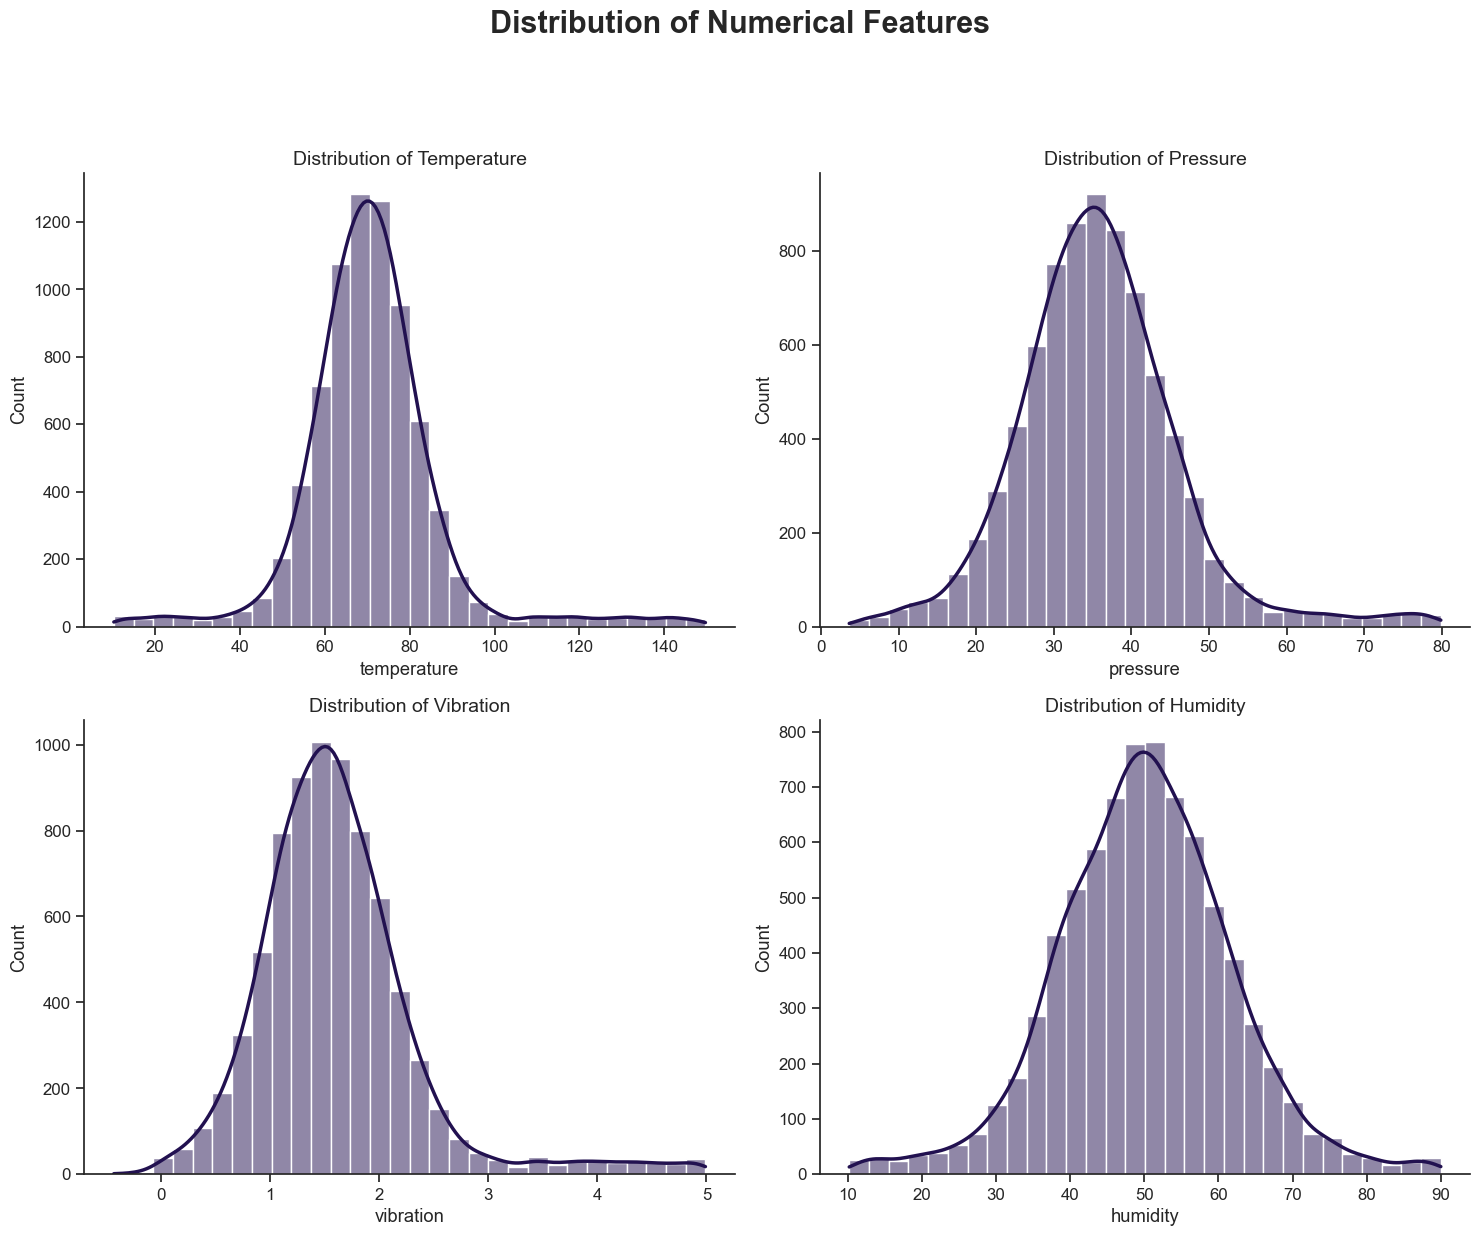


[INFO] Plotting distributions for categorical features...


C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')


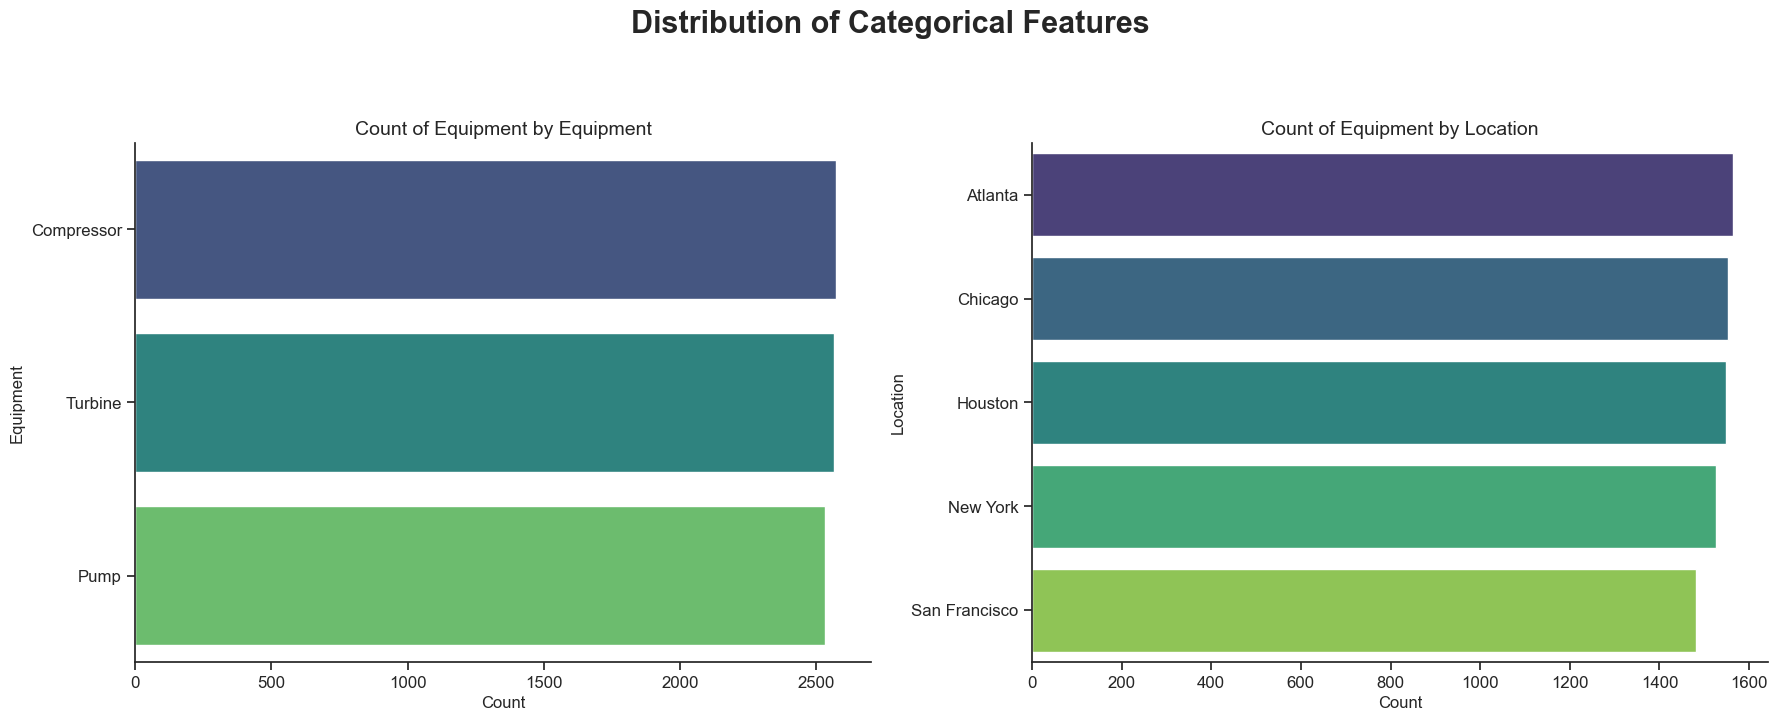


[INFO] Plotting distribution for the target variable 'faulty'...


C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target, data=df, palette='magma')


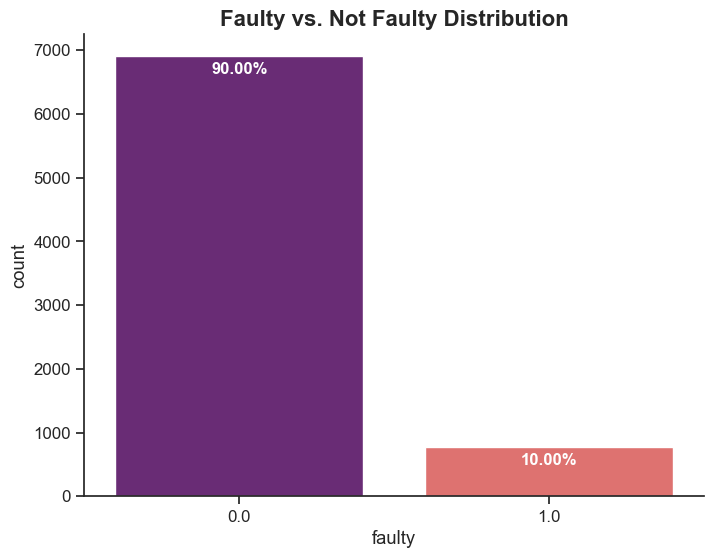


--- 4. Bivariate Analysis ---

[INFO] Analyzing numerical features against the 'faulty' status...


C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette='viridis')
C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette='viridis')
C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette='viridis')
C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:116: Future

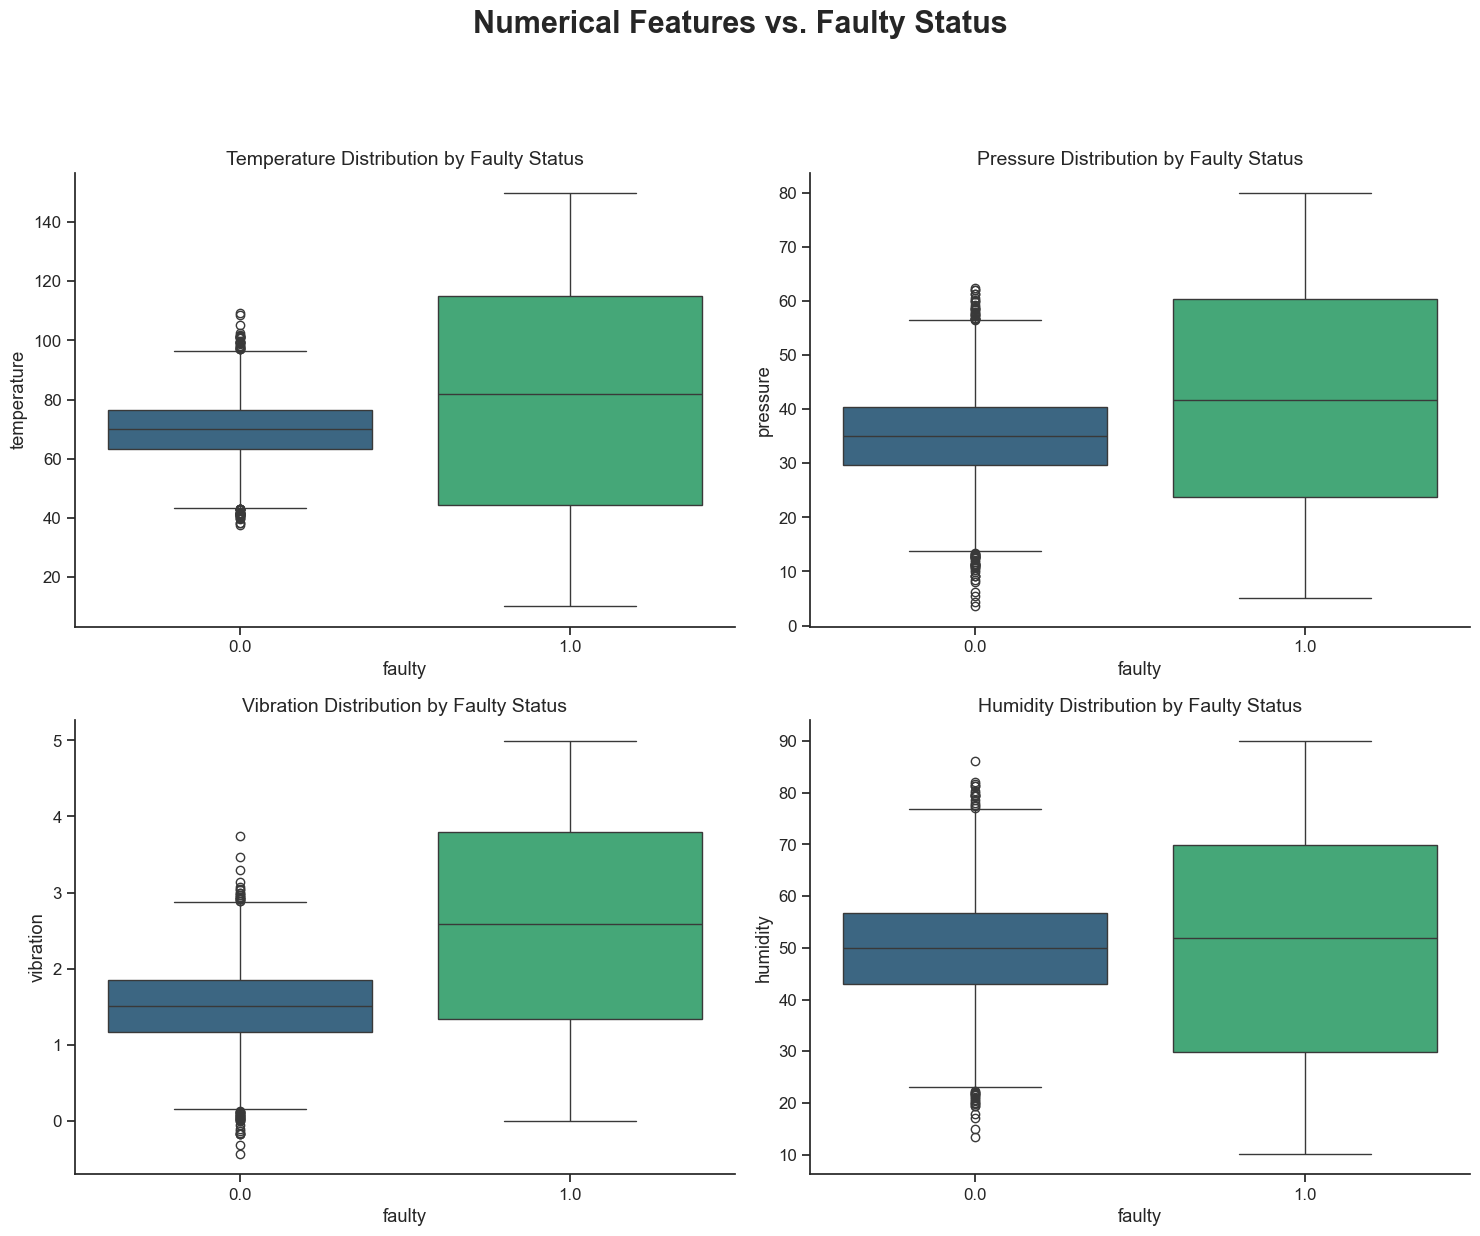


[INFO] Analyzing categorical features against the 'faulty' status...

Fault Rate by Equipment:
equipment
Turbine       0.100585
Compressor    0.099883
Pump          0.099448
Name: faulty, dtype: float64


C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fault_rate.index, y=fault_rate.values, palette='mako')


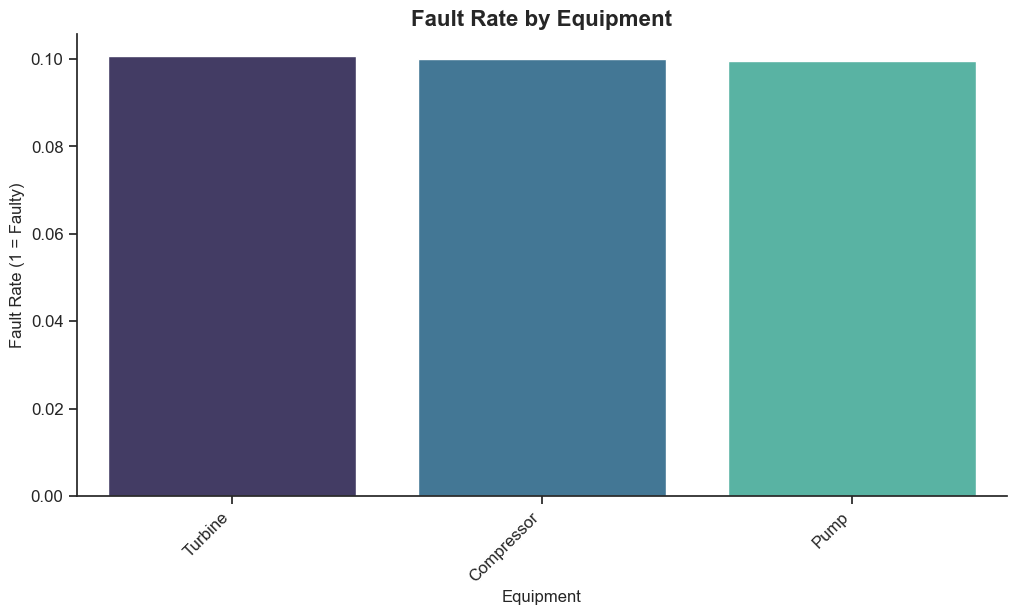


Fault Rate by Location:
location
San Francisco    0.114787
Chicago          0.103026
Houston          0.098837
New York         0.093709
Atlanta          0.090153
Name: faulty, dtype: float64


C:\Users\rouna\AppData\Local\Temp\ipykernel_8308\599472438.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fault_rate.index, y=fault_rate.values, palette='mako')


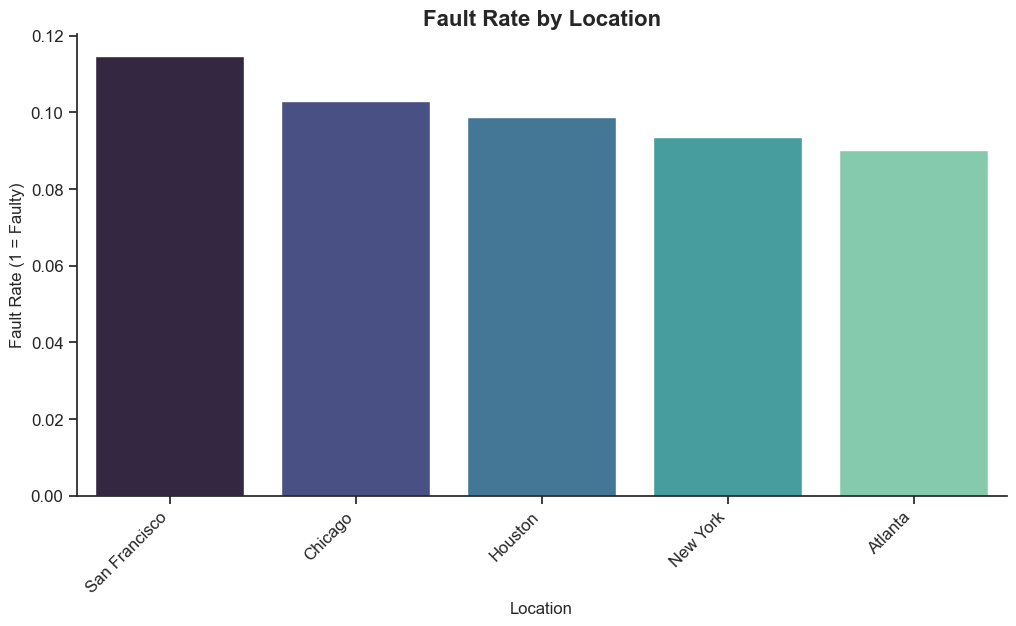


[INFO] Generating correlation matrix heatmap...


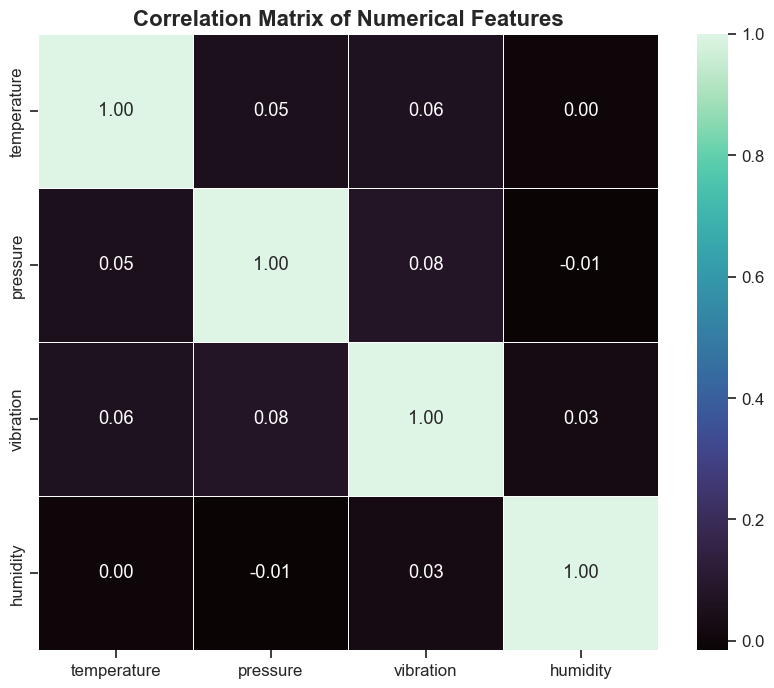


--- 5. Multivariate Analysis ---

[INFO] Generating pair plot, colored by 'faulty' status...


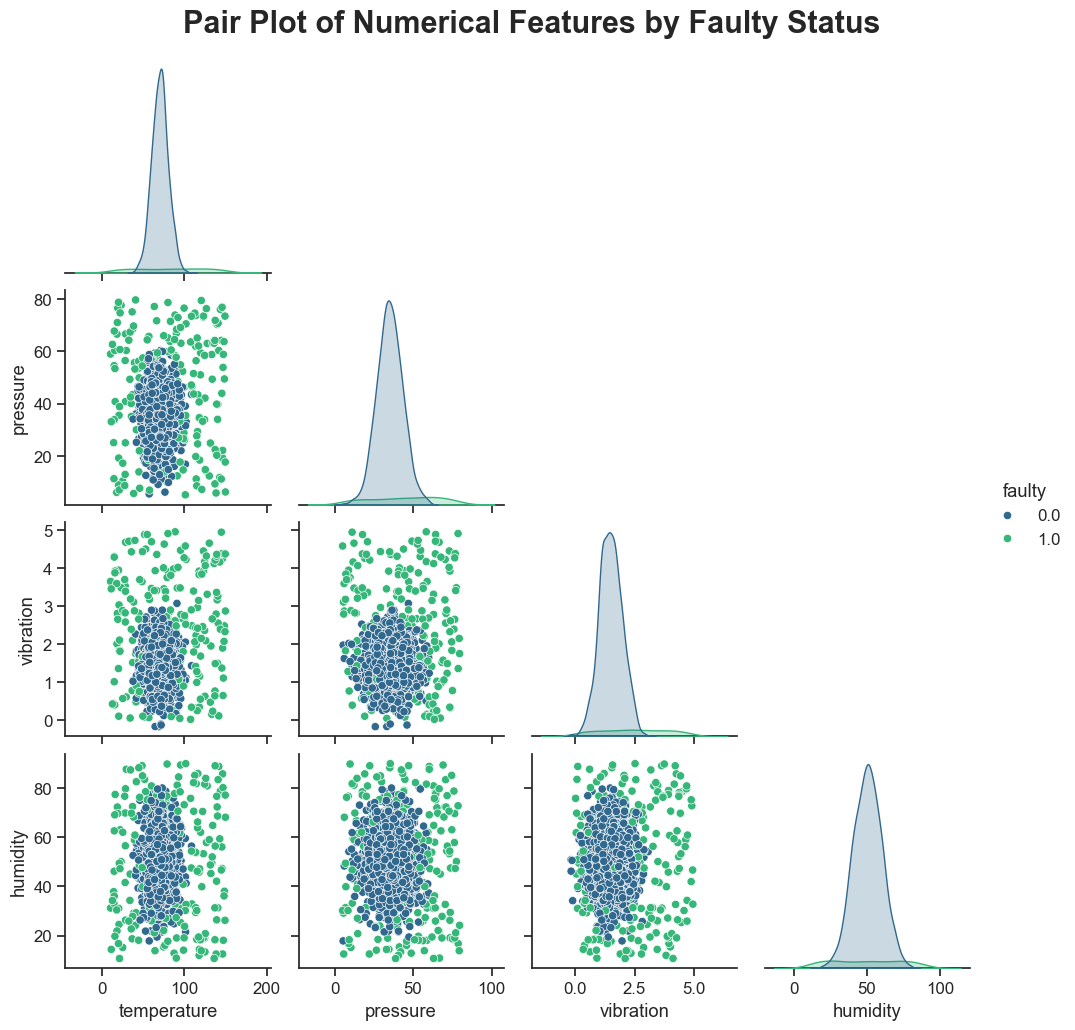


[INFO] Analyzing numerical readings across equipment types...


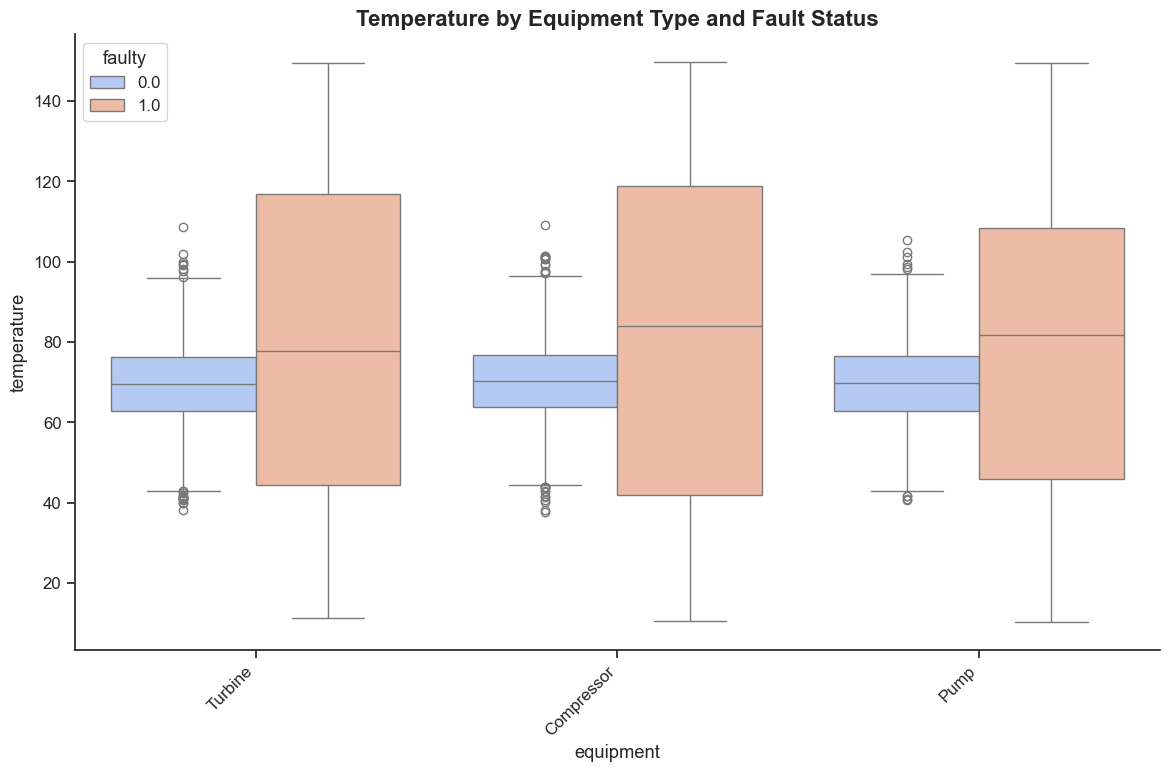

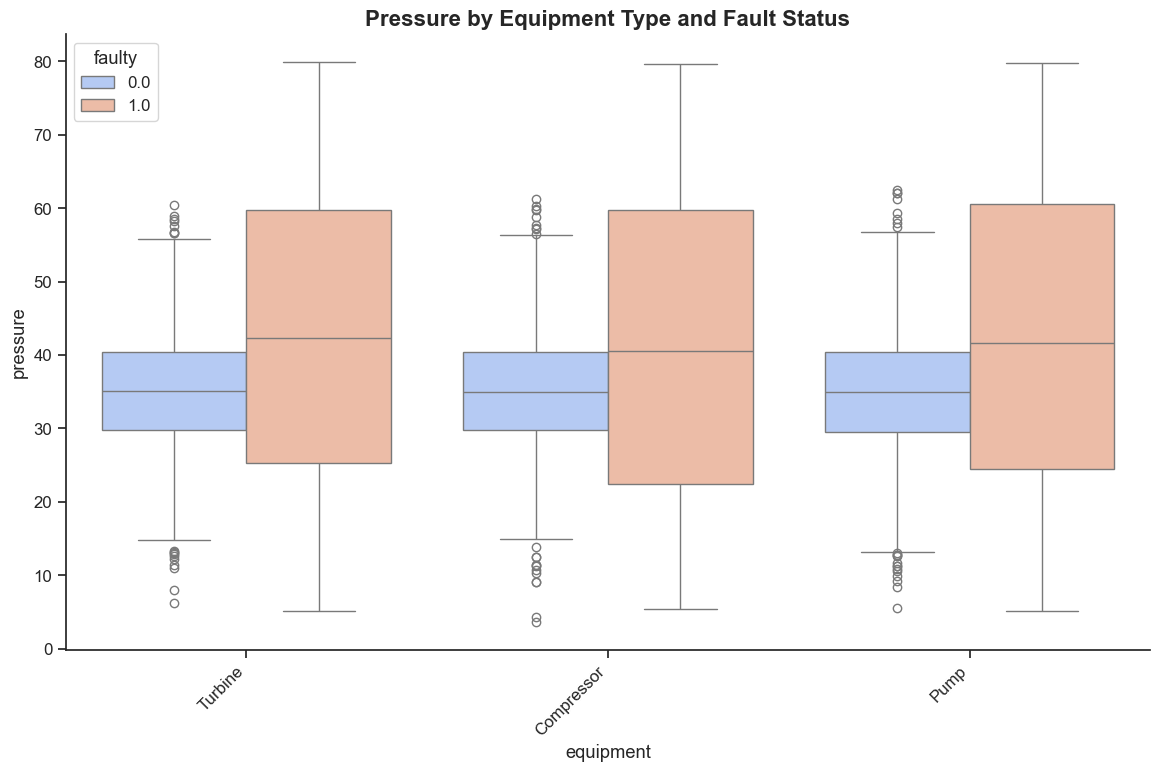

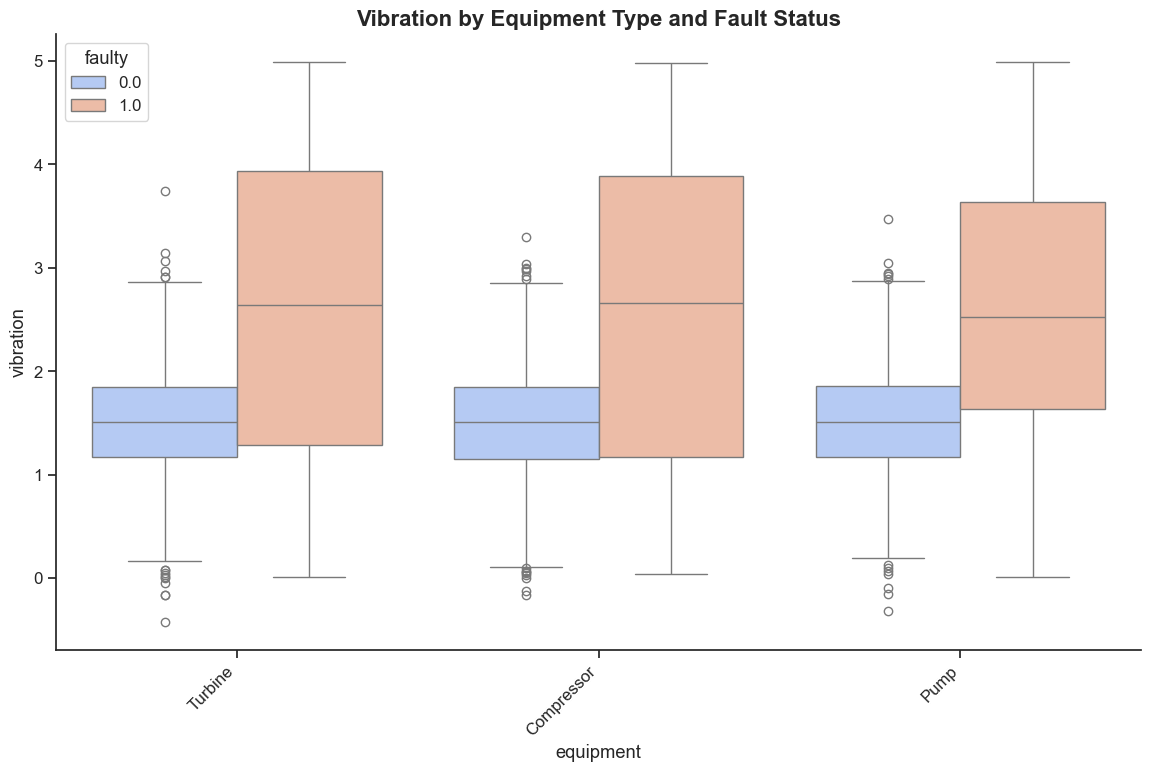

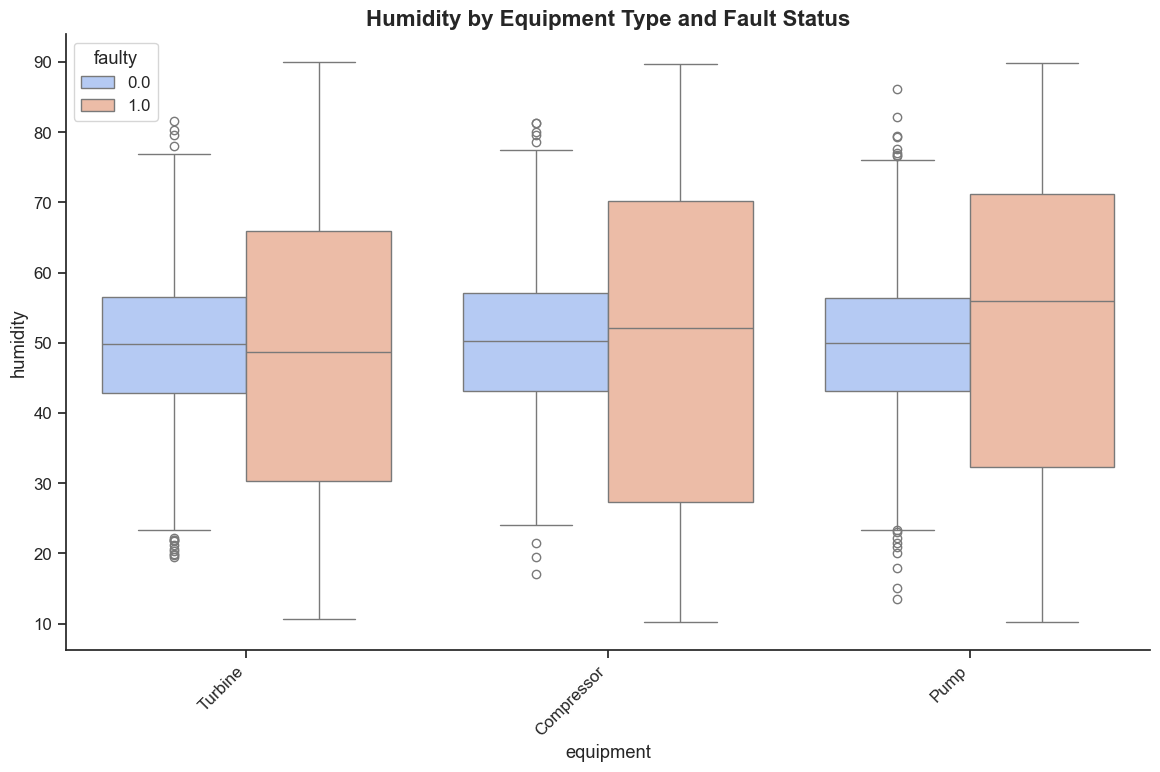


--- Comprehensive EDA Complete ---


In [8]:
def perform_comprehensive_eda(file_path):
    """
    Performs a comprehensive and visually attractive Exploratory Data Analysis (EDA)
    on the equipment fault dataset.

    This script assumes the dataset contains the following columns as per user specification:
    'temperature', 'pressure', 'vibration', 'humidity', 'equipment', 'location', 'faulty',
    and optionally 'timestamp'.

    Args:
        file_path (str): The path to the CSV data file.
    """
    # --- Aesthetics Setup ---
    # Set a consistent and attractive theme for all plots.
    # 'style="ticks"' creates a clean look, 'palette="magma"' provides a nice color scheme.
    # 'font_scale=1.1' increases font size for better readability.
    sns.set_theme(style="ticks", palette="magma", font_scale=1.1)


    # --- 1. Data Loading and Initial Inspection ---
    print("--- 1. Loading and Inspecting Data ---")
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded '{file_path}'.")
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    except Exception as e:
        print(f"An error occurred: {e}")
        print("\n[IMPORTANT] Please ensure the CSV file contains the specified columns: \n'temperature', 'pressure', 'vibration', 'humidity', 'equipment', 'location', 'faulty'")
        return

    print("\n[INFO] First 5 rows of the dataset:")
    print(df.head())
    print("\n[INFO] Dataframe information summary:")
    df.info()
    print("\n[INFO] Descriptive statistics for the dataset:")
    print(df.describe(include='all'))


    # --- 2. Data Cleaning and Preprocessing ---
    print("\n--- 2. Data Cleaning and Preprocessing ---")
    missing_values = df.isnull().sum()
    print("\n[INFO] Missing values per column:")
    print(missing_values)
    if missing_values.sum() == 0:
        print("-> No missing values found.")
    else:
        print("-> Missing values detected. Consider an imputation strategy.")

    if 'timestamp' in df.columns:
        print("\n[INFO] Converting 'timestamp' column to datetime objects.")
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        if df['timestamp'].isnull().any():
            print("-> Warning: Some timestamp values could not be parsed and were set to NaT.")
            df.dropna(subset=['timestamp'], inplace=True)


    # --- 3. Univariate Analysis ---
    print("\n--- 3. Univariate Analysis ---")
    numerical_features = ['temperature', 'pressure', 'vibration', 'humidity']
    categorical_features = ['equipment', 'location']
    target = 'faulty'

    # a) Distribution of Numerical Features
    print("\n[INFO] Plotting distributions for numerical features...")
    plt.figure(figsize=(15, 12))
    plt.suptitle("Distribution of Numerical Features", fontsize=22, y=1.03, weight='bold')
    for i, col in enumerate(numerical_features):
        plt.subplot(2, 2, i + 1)
        # Using a different color for the KDE line for better contrast
        sns.histplot(df[col], kde=True, bins=30, line_kws={'linewidth': 2.5, 'color': '#ff6347'})
        plt.title(f'Distribution of {col.capitalize()}', fontsize=14)
        sns.despine() # Removes top and right spines
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # b) Distribution of Categorical Features
    print("\n[INFO] Plotting distributions for categorical features...")
    plt.figure(figsize=(18, 7))
    plt.suptitle("Distribution of Categorical Features", fontsize=22, y=1.03, weight='bold')
    for i, col in enumerate(categorical_features):
        plt.subplot(1, 2, i + 1)
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Count of Equipment by {col.capitalize()}', fontsize=14)
        plt.xlabel('Count', fontsize=12)
        plt.ylabel(col.capitalize(), fontsize=12)
        sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # c) Target Variable Distribution
    print("\n[INFO] Plotting distribution for the target variable 'faulty'...")
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=target, data=df, palette='magma')
    plt.title('Faulty vs. Not Faulty Distribution', fontsize=16, weight='bold')
    total = len(df[target])
    for p in ax.patches:
        percentage = f'{(p.get_height()/total)*100:.2f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, weight='bold', color='white', xytext=(0, -15), textcoords='offset points')
    sns.despine()
    plt.show()


    # --- 4. Bivariate Analysis ---
    print("\n--- 4. Bivariate Analysis ---")

    # a) Numerical Features vs. Target
    print("\n[INFO] Analyzing numerical features against the 'faulty' status...")
    plt.figure(figsize=(15, 12))
    plt.suptitle("Numerical Features vs. Faulty Status", fontsize=22, y=1.03, weight='bold')
    for i, col in enumerate(numerical_features):
        plt.subplot(2, 2, i + 1)
        sns.boxplot(x=target, y=col, data=df, palette='viridis')
        plt.title(f'{col.capitalize()} Distribution by Faulty Status', fontsize=14)
        sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # b) Categorical Features vs. Target
    print("\n[INFO] Analyzing categorical features against the 'faulty' status...")
    for col in categorical_features:
        fault_rate = df.groupby(col)[target].mean().sort_values(ascending=False)
        print(f"\nFault Rate by {col.capitalize()}:\n{fault_rate}")
        plt.figure(figsize=(12, 6))
        # Using a full palette for a more dynamic bar chart
        sns.barplot(x=fault_rate.index, y=fault_rate.values, palette='mako')
        plt.title(f'Fault Rate by {col.capitalize()}', fontsize=16, weight='bold')
        plt.ylabel('Fault Rate (1 = Faulty)', fontsize=12)
        plt.xlabel(col.capitalize(), fontsize=12)
        plt.xticks(rotation=45, ha="right")
        sns.despine()
        plt.show()
    
    # c) Numerical vs. Numerical (Correlation)
    print("\n[INFO] Generating correlation matrix heatmap...")
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numerical_features].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='mako', fmt='.2f', linewidths=.5)
    plt.title('Correlation Matrix of Numerical Features', fontsize=16, weight='bold')
    plt.show()


    # --- 5. Multivariate Analysis ---
    print("\n--- 5. Multivariate Analysis ---")

    # a) Pair Plot
    print("\n[INFO] Generating pair plot, colored by 'faulty' status...")
    df_sample = df.sample(n=min(2000, len(df)), random_state=42)
    pair_plot = sns.pairplot(df_sample, hue=target, vars=numerical_features, palette='viridis', corner=True)
    pair_plot.fig.suptitle("Pair Plot of Numerical Features by Faulty Status", y=1.03, fontsize=22, weight='bold')
    plt.show()

    # b) Numerical vs. Categorical Analysis
    print("\n[INFO] Analyzing numerical readings across equipment types...")
    for num_col in numerical_features:
        plt.figure(figsize=(14, 8))
        sns.boxplot(x='equipment', y=num_col, data=df, hue=target, dodge=True, palette='coolwarm')
        plt.title(f'{num_col.capitalize()} by Equipment Type and Fault Status', fontsize=16, weight='bold')
        plt.xticks(rotation=45, ha="right")
        sns.despine()
        plt.show()
    

    # --- 6. Time Series Analysis (Optional) ---
    if 'timestamp' in df.columns:
        print("\n--- 6. Time Series Analysis ---")
        df_ts = df.set_index('timestamp').sort_index()
        
        print("[INFO] Plotting vibration and temperature over time...")
        fig, ax1 = plt.subplots(figsize=(18, 8))
        
        # Plot vibration on primary y-axis
        color = '#3498db' # A nice blue
        ax1.set_xlabel('Time', fontsize=12)
        ax1.set_ylabel('Vibration', color=color, fontsize=14)
        ax1.plot(df_ts.index, df_ts['vibration'], color=color, alpha=0.7, linewidth=2, label='Vibration')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(axis='y', linestyle='--', alpha=0.7)

        # Create a second y-axis for temperature
        ax2 = ax1.twinx()
        color = '#e74c3c' # A nice red
        ax2.set_ylabel('Temperature (°C)', color=color, fontsize=14)
        ax2.plot(df_ts.index, df_ts['temperature'], color=color, alpha=0.7, linewidth=2, label='Temperature')
        ax2.tick_params(axis='y', labelcolor=color)

        # Highlight faulty points with more prominent markers
        faulty_points = df_ts[df_ts[target] == 1]
        ax1.scatter(faulty_points.index, faulty_points['vibration'], 
                    color='black', s=100, zorder=5, label='Fault', 
                    edgecolor='white', linewidth=1.5)

        fig.tight_layout()
        plt.title('Vibration and Temperature Over Time with Faults Highlighted', fontsize=18, weight='bold')
        # Manually create a legend
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        sns.despine(right=False) # Keep right spine for the second axis
        plt.show()

    print("\n--- Comprehensive EDA Complete ---")

perform_comprehensive_eda(DATA_FILE)